# Desorfanización global: r*G y partición directa/indirecta

Ranking **global** (sobre todas las proteínas de la red, no sólo las de la
especie): curva de recuperación ρ(rG), su derivada λ(rG) y el corte **r\*G**
donde λ̃ cae al ruido de fondo (Fig 3A del paper 2016). Distribución de `rSS` y
partición de los aciertos en **inferencia directa** (el blanco verdadero está
entre las semillas) e **indirecta** (sólo se llega por la capa de afiliaciones).

No vuelve a correr el modelo: post-procesa lo que dejó el notebook `01`, que ya
guarda `rG`, `rSS` y la clase de inferencia por droga.

Origen: la desorfanización global de la versión v3 (fuera de este repositorio).
Salidas: `03_ranking_global.csv`, `03_curva_recuperacion.csv`, `03_rg_estrella.csv`,
`03_rg_sensibilidad.csv`,
`03_clases_inferencia.csv`.

## Imports

In [1]:
import sys, os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")          # antes de numpy: un hilo por proceso

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from pathlib import Path
# raiz del repositorio: se busca hacia arriba la carpeta que tiene DB/,
# asi el notebook corre desde donde sea que se haya clonado
RAIZ = Path.cwd()
while not (RAIZ / "DB").is_dir() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "comun"))
sys.path.insert(0, str(RAIZ / "huerfanas"))
%load_ext autoreload
%autoreload 2
import tdr, nucleo as nf
import funciones_huerfanas as fh              # el .py de esta carpeta
import figuras as F                        # comun/figuras.py: las figuras, desde las tablas

SALIDAS = tdr.out("huerfanas")
FIGURAS = SALIDAS / "figuras"
NB      = "03"                             # numero de este notebook: prefija todo lo que genere
n_core  = tdr.N_CORE_DEFAULT                # 20 salvo TDR_NCORE

plt = tdr.estilo()
SALIDAS

PosixPath('/data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/huerfanas_out')

## Datos

In [2]:
HUERFANAS = tdr.out("huerfanas")
res = fh.cargar_resultados(HUERFANAS, "01", patron="*_pseudohuerfanas")
k1  = pd.read_csv(HUERFANAS / "01_k1_drugs.csv")
res = res.merge(k1[["drug_id", "sp_id", "grupo"]].rename(columns={"sp_id": "especie"}),
                on=["drug_id", "especie"], how="left")
res.shape, tdr.leer_meta(HUERFANAS, "01")["fecha"]

((7782, 14), '2026-09-24 16:11')

## Acondicionamiento

In [3]:
con_rg = res[res["rG"].notna()].copy()
print(f"{len(con_rg)} de {len(res)} drogas con ranking global "
      f"({len(con_rg)/len(res):.1%}); el resto tiene semilla nula")
print(con_rg["clase"].value_counts(normalize=True).round(3).to_dict())


2509 de 7782 drogas con ranking global (32.2%); el resto tiene semilla nula
{'indirecta': 0.556, 'directa': 0.444}


## Corrida

In [4]:
# celda de corrida: el ciclo se lee aca
curva = fh.curva_recuperacion(con_rg["rG"], l_max=1000)
curva, rg_star = fh.r_g_estrella(curva)
# r*G es un corte operativo, no un parametro identificado: cuanto se mueve con k_sigma
rg_sens = pd.concat([fh.r_g_estrella(curva, k_sigma=k)[1] for k in (2.0, 2.5, 3.0, 3.5, 4.0)],
                    ignore_index=True)

rss = (con_rg.groupby(con_rg["rSS"].astype(int)).size().reset_index(name="n")
       .rename(columns={"rSS": "posicion"}))
rss["frac_acumulada"] = rss["n"].cumsum() / rss["n"].sum()

clases = con_rg.groupby(["clase", "especie"]).agg(
    n=("drug_id", "size"), rG_mediana=("rG", "median"), rSS_mediana=("rSS", "median")
).reset_index()

con_rg.to_csv(SALIDAS / f"{NB}_ranking_global.csv", index=False)
curva.to_csv(SALIDAS / f"{NB}_curva_recuperacion.csv", index=False)
rg_star.to_csv(SALIDAS / f"{NB}_rg_estrella.csv", index=False)
rg_sens.to_csv(SALIDAS / f"{NB}_rg_sensibilidad.csv", index=False)
rss.to_csv(SALIDAS / f"{NB}_rss_distribucion.csv", index=False)
clases.to_csv(SALIDAS / f"{NB}_clases_inferencia.csv", index=False)
# las de semilla informativa, mas de cerca que con frank < 0.1
inf, topk = fh.analisis_informativa(res)
inf.to_csv(SALIDAS / f"{NB}_informativa.csv", index=False)
topk.to_csv(SALIDAS / f"{NB}_informativa_topk.csv", index=False)

fh.escribir_meta(SALIDAS, NB, notebook="03_desorfanizacion_global.ipynb",
                 params={"l_max": 1000, "k_sigma": 3.0}, fuente_nb="01",
                 r_g_estrella=float(rg_star["r_g_estrella"].iloc[0]))

  meta -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/huerfanas_out/03_meta.json


{'notebook': '03_desorfanizacion_global.ipynb',
 'nb': '03',
 'fecha': '2026-09-24 16:29',
 'params': {'l_max': 1000, 'k_sigma': 3.0},
 'n_core': None,
 'tablas_db': {'00_specie_target.csv': '2026-09-08',
  '01_clusters_fingerprint.csv': '2026-09-08',
  '01_edges_clusters_fingerprint.part00.csv.gz': '2026-09-08',
  '01_edges_clusters_fingerprint.part01.csv.gz': '2026-09-08',
  '02_clusters_subestructure.csv': '2026-09-08',
  '02_edges_clusters_subestructure.csv': '2026-09-08',
  '03_bioactivities_organism_compound.csv': '2026-09-08',
  '03_bioactivities_target_compound.csv': '2026-09-08',
  '04a_interpro.csv': '2026-09-08',
  '04b_orthomcl.csv': '2026-09-08'},
 'python': '3.12.11',
 'pandas': '3.0.5',
 'fuente_nb': '01',
 'r_g_estrella': 76.0}

# Resultados

Desde acá no se toca la base: cada figura lee sus tablas de `resultados/` y la
dibuja `F.dibujar(...)` (las funciones están en `figuras_huerfanas.py`). Para
regenerarlas sin volver a pagar la corrida alcanza con la celda de imports y esta
sección, o, desde la raíz del repositorio:

    python comun/figuras.py huerfanas

In [5]:
curva   = pd.read_csv(SALIDAS / f"{NB}_curva_recuperacion.csv")
rg_star = pd.read_csv(SALIDAS / f"{NB}_rg_estrella.csv")
rss     = pd.read_csv(SALIDAS / f"{NB}_rss_distribucion.csv")
clases  = pd.read_csv(SALIDAS / f"{NB}_clases_inferencia.csv")
rg_star

,lambda_inf,sigma,umbral,r_g_estrella,k_sigma,desde
0,0.528062,0.830646,3.019999,76.0,3.0,50


  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/huerfanas_out/figuras/03_f01_distribucion_rg.pdf


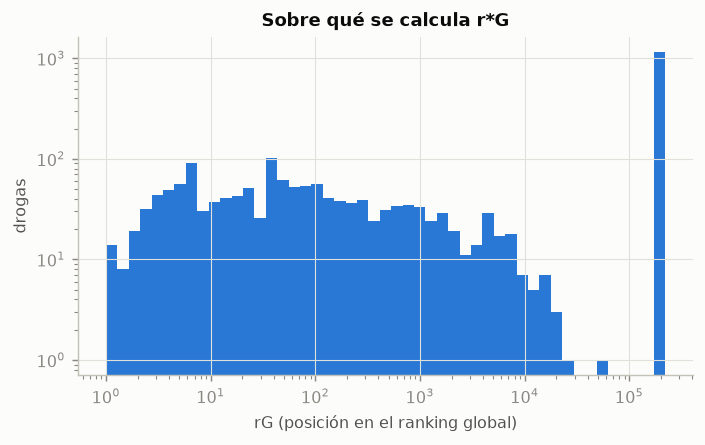

In [6]:
F.dibujar("03_f01_distribucion_rg");

  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/huerfanas_out/figuras/03_f02_recuperacion.pdf


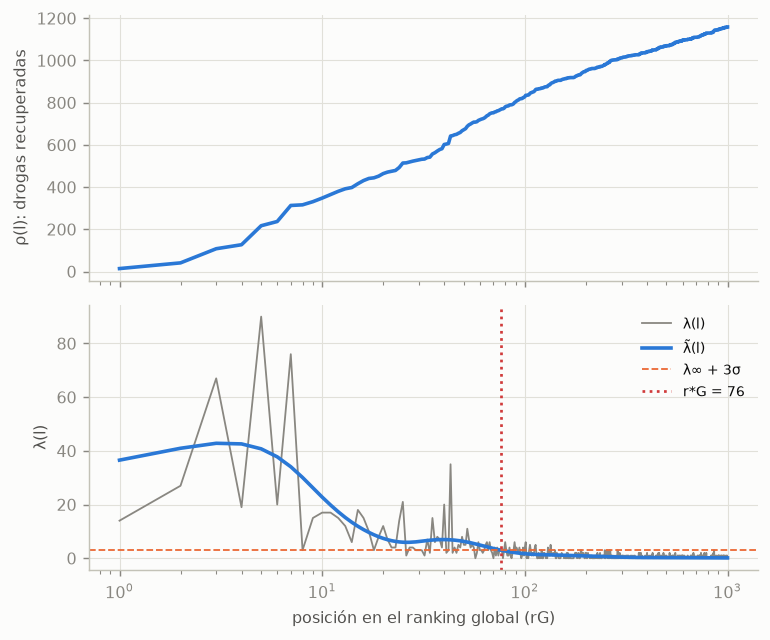

In [7]:
F.dibujar("03_f02_recuperacion");

  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/huerfanas_out/figuras/03_f03_rss.pdf


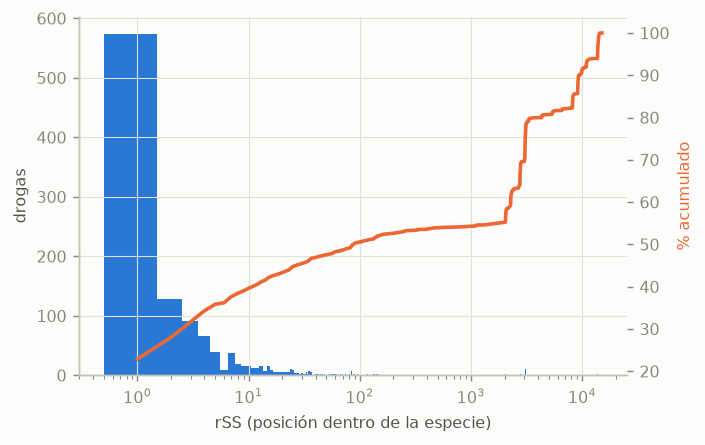

In [8]:
F.dibujar("03_f03_rss");

  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/huerfanas_out/figuras/03_f04_directa_indirecta.pdf


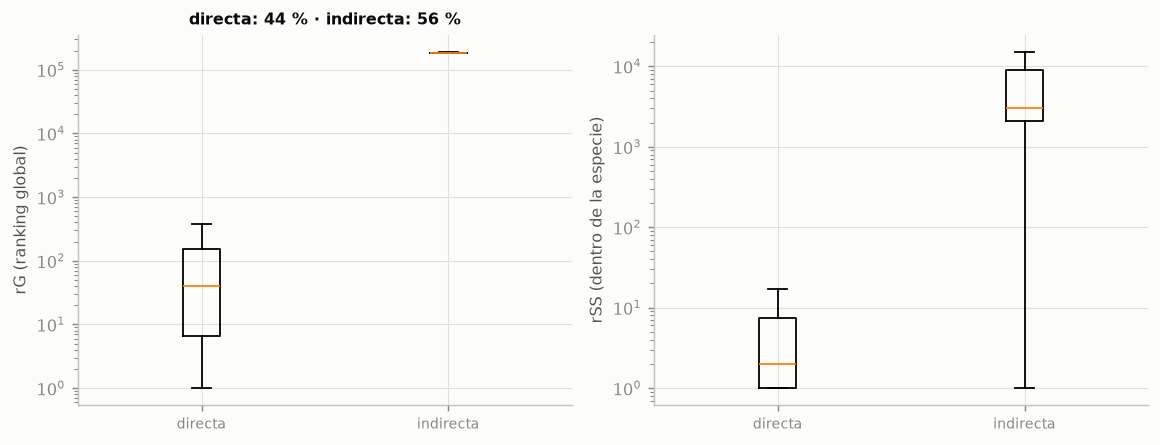

In [9]:
# Partición directa / indirecta; el paper 2016 reporta 68 % / 32 %
F.dibujar("03_f04_directa_indirecta");

## Semilla informativa, más de cerca

`frank < 0.1` es quedar entre el 10 % de arriba de las proteínas de la especie
(varios cientos o miles): casi todas las informativas lo cumplen y el número no
discrimina. Acá se mira la
posición absoluta del blanco (`rSS`), la partición directa / indirecta, el
tamaño de la semilla y el organismo.

In [10]:
inf  = pd.read_csv(SALIDAS / f"{NB}_informativa.csv")
topk = pd.read_csv(SALIDAS / f"{NB}_informativa_topk.csv")
print(f"{len(inf)} informativas: {inf['clase'].value_counts().to_dict()}, "
      f"empates en el {inf['empate'].mean():.0%}")
topk[topk["k"].isin([1, 3, 5, 10, 50, 100, 1000])].round(3)

1365 informativas: {'directa': 1113, 'indirecta': 252}, empates en el 40%


,k,todas,azar,directa,indirecta
0,1,0.297,0.000,0.341,0.099
2,3,0.555,0.000,0.628,0.230
4,5,0.643,0.001,0.720,0.306
9,10,0.721,0.001,0.793,0.401
23,50,0.873,0.007,0.919,0.671
29,100,0.929,0.013,0.966,0.766
49,1000,0.998,0.133,1.000,0.988


In [11]:
inf.groupby("clase")[["rSS", "frank", "rG", "n_semilla"]].median()

,rSS,frank,rG,n_semilla
clase,,,,
directa,2.0,0.000246,39.50,5.0
indirecta,20.0,0.002134,488.75,25.5


  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/huerfanas_out/figuras/03_f05_semilla_informativa.pdf


  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/huerfanas_out/figuras/03_f06_semilla_rss.pdf


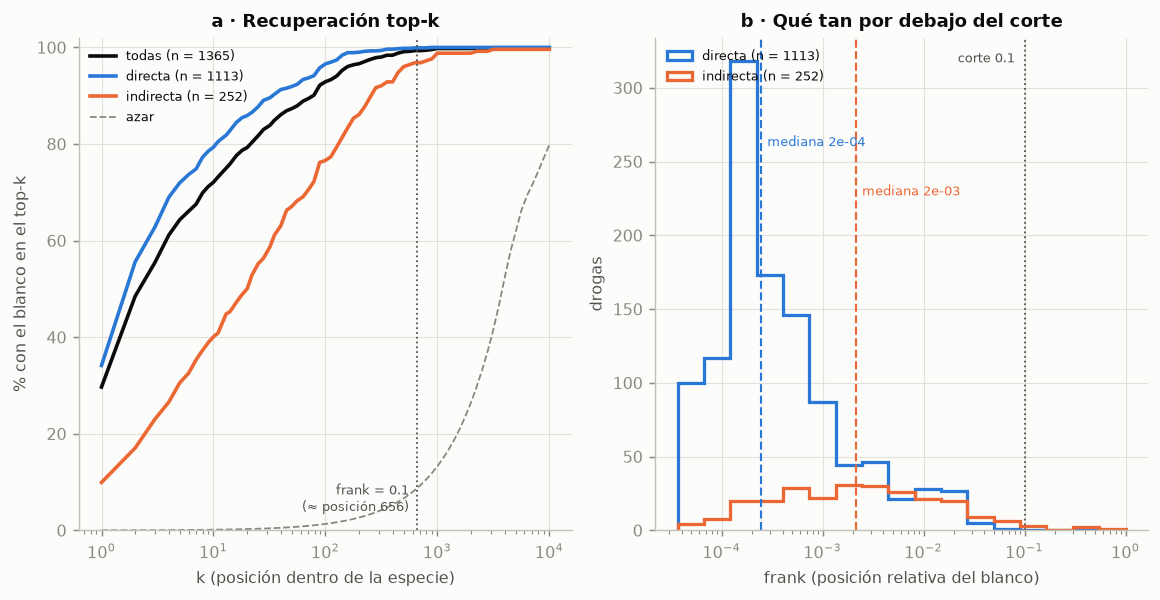

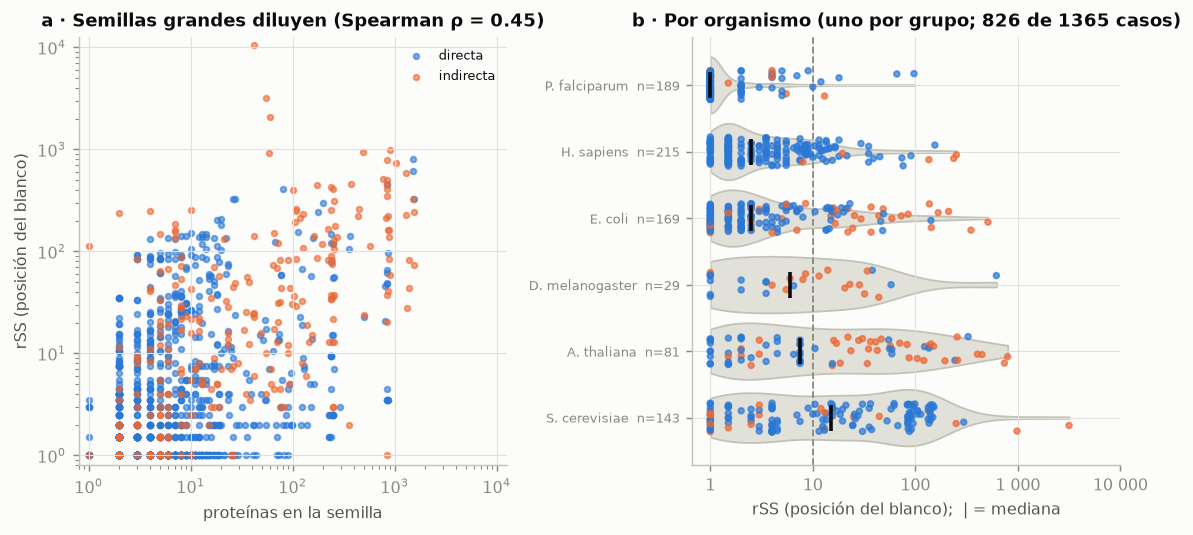

In [12]:
F.dibujar("03_f05_semilla_informativa");
F.dibujar("03_f06_semilla_rss");